# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import solve_ivp

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [2]:
t_analytic = np.sqrt(2*4000/scipy.constants.g)
print(f"The naive classical time without air resistance is {t_analytic:.4f} seconds.")

The naive classical time without air resistance is 28.5617 seconds.


  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  3.030e-01 ...  2.970e+01  3.000e+01]
        y: [[ 0.000e+00 -4.503e-01 ... -4.324e+03 -4.413e+03]
            [ 0.000e+00 -2.972e+00 ... -2.912e+02 -2.942e+02]]
      sol: None
 t_events: [array([ 2.856e+01])]
 y_events: [array([[-4.000e+03, -2.801e+02]])]
     nfev: 44
     njev: 0
      nlu: 0
As expected, there are no differences between the analytic solution and the differential solution in the case where alpha=0, since this implies no drag, and the analytic solution is therefore precise.


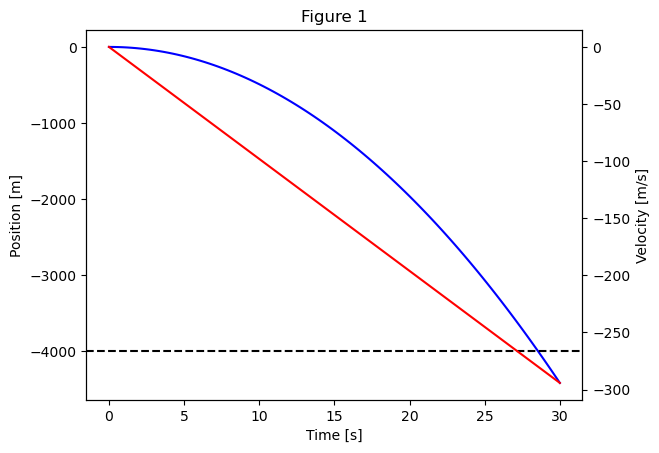

In [3]:
alpha = 0
gamma = 2

def derivatives(t,s):
    assert len(s) == 2
    y, v = s
    dydt = v
    dvdt = -scipy.constants.g+alpha*(np.abs(v))**(gamma)
    return [dydt, dvdt]

x_stop = -4000

def ground(t,s):
    return s[0] - x_stop

y0 = [0.0, 0.0]
t_span = (0,30)
t_eval = np.linspace(*t_span, 100)


soln = solve_ivp(derivatives, t_span, y0, t_eval=t_eval, events=ground)
t = soln.t
x = soln.y[0]
v = soln.y[1]

fig, ax = plt.subplots()
ax.plot(t,x,label="pos", color="blue")
ax2 = ax.twinx()
ax2.plot(t,v,label="vel", color="red")
ax.axhline(-4000,color="black", linestyle="--")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Position [m]")
ax2.set_ylabel("Velocity [m/s]")
ax.set_title("Figure 1")

print(soln)
print("As expected, there are no differences between the analytic solution and the differential solution in the case where alpha=0, since this implies no drag, and the analytic solution is therefore precise.")

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  3.030e-01 ...  2.970e+01  3.000e+01]
        y: [[ 6.378e+06  6.378e+06 ...  6.374e+06  6.374e+06]
            [ 0.000e+00 -2.972e+00 ... -2.912e+02 -2.941e+02]]
      sol: None
 t_events: [array([ 2.856e+01])]
 y_events: [array([[ 6.374e+06, -2.801e+02]])]
     nfev: 44
     njev: 0
      nlu: 0
The 4km drop is miniscule relative to the Earth's radius of nearly 6000km, so the change in g is also minimal. This is consistent with our result that shows essentially no change in the fall time. However, if the effect where to be magnified (i.e. by doing a 1000km drop), we would see a reduction in the acceleration of the object, and therefore an increase in fall time.


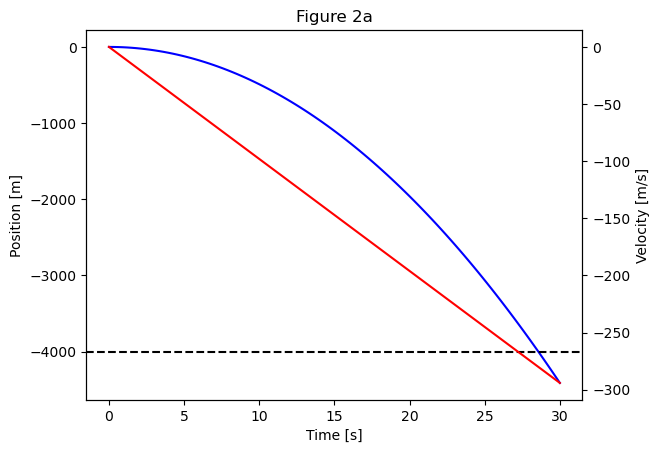

In [4]:
#no drag, sections 1, 2
r_earth = 6.3781E6
r_0 = r_earth
g_0 = scipy.constants.g

def derivatives2(t,s):
    assert len(s) == 2
    r, v = s
    drdt = v
    dvdt = -g_0*(r/r_earth)
    return [drdt, dvdt]

r_stop = -4000+r_earth

def ground(t,s):
    return s[0] - r_stop

y0 = [r_earth, 0.0]
t_span = (0,30)
t_eval = np.linspace(*t_span, 100)

soln = solve_ivp(derivatives2, t_span, y0, t_eval=t_eval, events=ground)
t = soln.t
x = soln.y[0]-r_earth
v = soln.y[1]

fig, ax = plt.subplots()
ax.plot(t,x,label="pos", color="blue")
ax2 = ax.twinx()
ax2.plot(t,v,label="vel", color="red")
ax.axhline(-4000,color="black", linestyle="--")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Position [m]")
ax2.set_ylabel("Velocity [m/s]")
ax.set_title("Figure 2a")

print(soln)
print("The 4km drop is miniscule relative to the Earth's radius of nearly 6000km, so the change in g is also minimal. This is consistent with our result that shows essentially no change in the fall time. However, if the effect where to be magnified (i.e. by doing a 1000km drop), we would see a reduction in the acceleration of the object, and therefore an increase in fall time.")

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.523e-01 ...  8.955e+01  9.000e+01]
        y: [[ 6.378e+06  6.378e+06 ...  6.374e+06  6.374e+06]
            [ 0.000e+00 -4.424e+00 ... -5.011e+01 -5.012e+01]]
      sol: None
 t_events: [array([ 8.332e+01])]
 y_events: [array([[ 6.374e+06, -5.013e+01]])]
     nfev: 134
     njev: 0
      nlu: 0


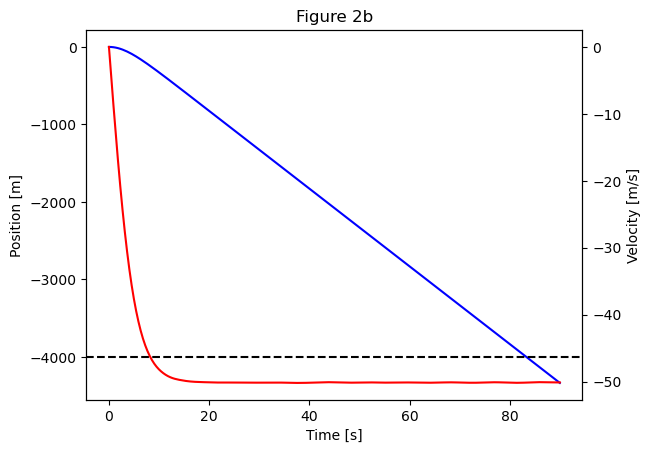

In [5]:
#with drag, section 3

r_earth = 6.3781E6
r_0 = r_earth
g_0 = scipy.constants.g
alpha = 0.0039
gamma = 2

def derivatives2(t,s):
    assert len(s) == 2
    r, v = s
    drdt = v
    dvdt = -g_0*(r/r_earth)+alpha*(np.abs(v))**(gamma)
    return [drdt, dvdt]

r_stop = -4000+r_earth

def ground(t,s):
    return s[0] - r_stop

y0 = [r_earth, 0.0]
t_span = (0,90)
t_eval = np.linspace(*t_span, 200)

soln = solve_ivp(derivatives2, t_span, y0, t_eval=t_eval, events=ground)
t = soln.t
x = soln.y[0]-r_earth
v = soln.y[1]

fig, ax = plt.subplots()
ax.plot(t,x,label="pos", color="blue")
ax2 = ax.twinx()
ax2.plot(t,v,label="vel", color="red")
ax.axhline(-4000,color="black", linestyle="--")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Position [m]")
ax2.set_ylabel("Velocity [m/s]")
ax.set_title("Figure 2b")

print(soln)

Section 3 Analysis: We see that having a drag force substantially slows down the falling object, to the point that it begins to fall not at a continuously accelrating velocity, but rather at a constant one because the drag force grows sufficiently to balance the force due to gravity. As a result it takes much longer for the mass to hit the ground, in this case, a full 83.32 seconds after being dropped, as compared to just over 28.5 seconds before.

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




Using $F = ma = m\frac{dv}{dt}$, we get the following coupled system of equations:

$$\frac{dx}{dt} = v_x$$
$$\frac{dy}{dt} = v_y$$
$$\frac{dv_x}{dt} = 2 \Omega v_y$$ (from $F_{cx}=2m \Omega v_y$)
$$\frac{dv_y}{dt} = -g_0 \frac{y}{y_E} + \alpha |v_y|^{\gamma} - 2 \Omega v_x$$ (adds the $F_{cy} = 2m \Omega v_x$ term onto our existing equation)

We observe that in the no drag case, the x-position of the object crosses the line x=-5 (hits the side of the shaft), before it hits the bottom


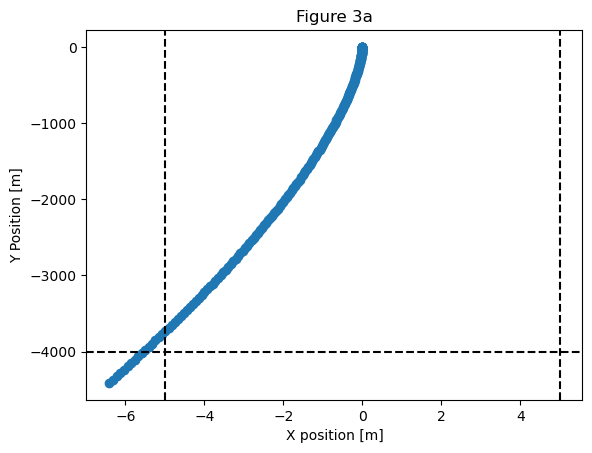

In [6]:
#without drag

r_earth = 6.3781E6
r_0 = r_earth
g_0 = scipy.constants.g
alpha = 0.0039
gamma = 0
omega = 7.2727e-5

def derivatives3(t,s):
    assert len(s) == 4
    x, y, v_x, v_y = s
    dxdt = v_x
    dydt = v_y
    dvxdt = 2*omega*v_y
    dvydt = -g_0*(y/r_earth)+alpha*(np.abs(v_y))**(gamma)-2*omega*v_x
    return [dxdt, dydt, dvxdt, dvydt]

y0 = [0.0, r_earth, 0.0, 0.0]
t_span = (0,30)
t_eval = np.linspace(*t_span, 200)

soln = solve_ivp(derivatives3, t_span, y0, t_eval=t_eval, events=ground)
t = soln.t
x = soln.y[0]
y = soln.y[1]-r_earth

fig, ax = plt.subplots()
ax.scatter(x,y)
ax.axhline(-4000,color="black", linestyle="--")
ax.axvline(-5,color="black", linestyle="--")
ax.axvline(5,color="black", linestyle="--")
ax.set_xlabel("X position [m]")
ax.set_ylabel("Y Position [m]")
ax.set_title("Figure 3a")

print("We observe that in the no drag case, the x-position of the object crosses the line x=-5 (hits the side of the shaft), before it hits the bottom")

Drag slows the rate of fall, so we expect to see the object hit the edge of the shaft earlier than it does in the no drag case. This is indeed what we observe.


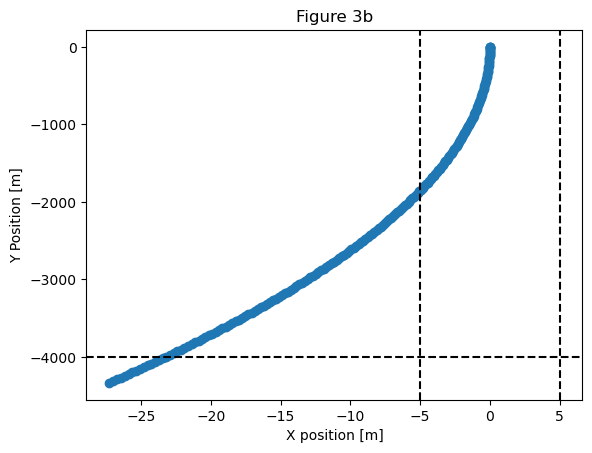

In [7]:
#with drag

r_earth = 6.3781E6
r_0 = r_earth
g_0 = scipy.constants.g
alpha = 0.0039
gamma = 2
omega = 7.2727e-5

def derivatives3(t,s):
    assert len(s) == 4
    x, y, v_x, v_y = s
    dxdt = v_x
    dydt = v_y
    dvxdt = 2*omega*v_y
    dvydt = -g_0*(y/r_earth)+alpha*(np.abs(v_y))**(gamma)-2*omega*v_x
    return [dxdt, dydt, dvxdt, dvydt]

y0 = [0.0, r_earth, 0.0, 0.0]
t_span = (0,90)
t_eval = np.linspace(*t_span, 200)

soln = solve_ivp(derivatives3, t_span, y0, t_eval=t_eval, events=ground)
t = soln.t
x = soln.y[0]
y = soln.y[1]-r_earth

fig, ax = plt.subplots()
ax.scatter(x,y)
ax.axhline(-4000,color="black", linestyle="--")
ax.axvline(-5,color="black", linestyle="--")
ax.axvline(5,color="black", linestyle="--")
ax.set_xlabel("X position [m]")
ax.set_ylabel("Y Position [m]")
ax.set_title("Figure 3b")

print("Drag slows the rate of fall, so we expect to see the object hit the edge of the shaft earlier than it does in the no drag case. This is indeed what we observe.")

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e+00 ...  2.999e+03  3.000e+03]
        y: [[ 6.378e+06  6.378e+06 ... -5.342e+06 -5.337e+06]
            [ 0.000e+00 -9.810e+00 ...  4.321e+03  4.329e+03]]
      sol: None
 t_events: [array([ 1.267e+03]), array([], dtype=float64)]
 y_events: [array([[ 1.863e-09, -7.909e+03]]), array([], dtype=float64)]
     nfev: 68
     njev: 0
      nlu: 0
The rotational period for an orbiting satelite just above the Earth's surface is given by 5069.3712.


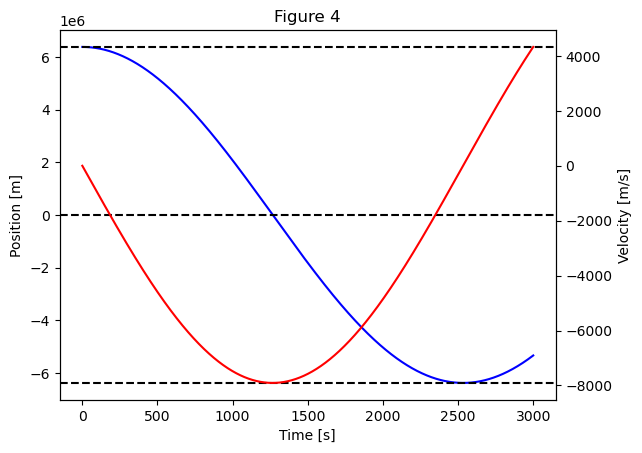

In [8]:
#no drag, no coriolis, just g effects
r_earth = 6.3781E6
r_0 = r_earth
g_0 = scipy.constants.g

def derivatives4(t,s):
    assert len(s) == 2
    y, v = s
    dydt = v
    dvdt = -g_0*(y/r_earth)
    return [dydt, dvdt]

def center(t,s):
    return s[0]

def other_side(t,s):
    return s[0] + r_earth

y0 = [r_earth, 0.0]
t_span = (0,3000)
t_eval = np.linspace(*t_span, 3000)

soln = solve_ivp(derivatives4, t_span, y0, t_eval=t_eval, events= [center, other_side])
t = soln.t
x = soln.y[0]
v = soln.y[1]

fig, ax = plt.subplots()
ax.plot(t,x,label="pos", color="blue")
ax2 = ax.twinx()
ax2.plot(t,v,label="vel", color="red")
ax.axhline(0,color="black", linestyle="--")
ax.axhline(r_earth,color="black", linestyle="--")
ax.axhline(-r_earth,color="black", linestyle="--")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Position [m]")
ax2.set_ylabel("Velocity [m/s]")
ax.set_title("Figure 4")

print(soln)

m_earth = 5.972E24
period = 2*np.pi*r_earth*np.sqrt(r_earth/(scipy.constants.G*m_earth))
print(f"The rotational period for an orbiting satelite just above the Earth's surface is given by {period:.4f}.")

We observe that it takes about 1267 seconds for the object to reach the center of the Earth, and since this motion appears sinusoidal, we expect that it takes twice that time to reach the other edge, or 2534 seconds, which is confirmed by our plot, suggesting a period of about 5068 seconds. Note that the rotational period of an orbiting satelite at the Earth's surface is calculated to be just over 5069 seconds, which is within a prescision error of our other calculation. This suggests the period is actually the same.

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

Text(0.5, 1.0, 'Figure 5')

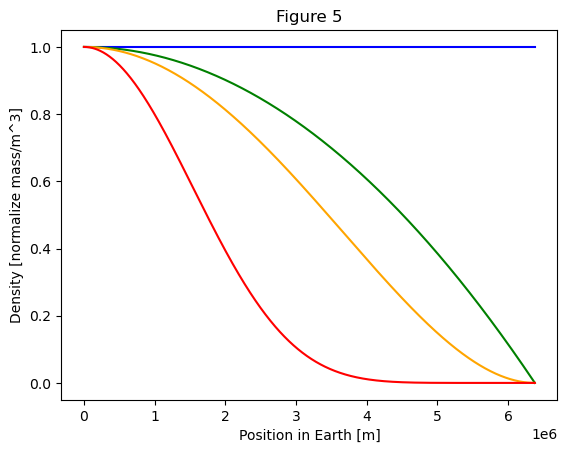

In [9]:
from scipy.integrate import quad

def density(r,n):
    return (1-r**2/r_earth**2)**n

r = np.linspace(0,r_earth,1000)


fig, ax = plt.subplots()
ax.plot(r,density(r,0),label="n=0", color="blue")
ax.plot(r,density(r,1),label="n=1", color="green")
ax.plot(r,density(r,2),label="n=2", color="orange")
ax.plot(r,density(r,9),label="n=3", color="red")
ax.set_xlabel("Position in Earth [m]")
ax.set_ylabel("Density [normalize mass/m^3]")
ax.set_title("Figure 5")

### Part 5, Section B (Forces)

C:\Users\danya\AppData\Local\Temp\ipykernel_19580\3485031058.py:32: RuntimeWarning: invalid value encountered in divide
  F0 = -scipy.constants.G*M0/(r**2)
C:\Users\danya\AppData\Local\Temp\ipykernel_19580\3485031058.py:33: RuntimeWarning: invalid value encountered in divide
  F1 = -scipy.constants.G*M1/(r**2)
C:\Users\danya\AppData\Local\Temp\ipykernel_19580\3485031058.py:34: RuntimeWarning: invalid value encountered in divide
  F2 = -scipy.constants.G*M2/(r**2)
C:\Users\danya\AppData\Local\Temp\ipykernel_19580\3485031058.py:35: RuntimeWarning: invalid value encountered in divide
  F9 = -scipy.constants.G*M9/(r**2)


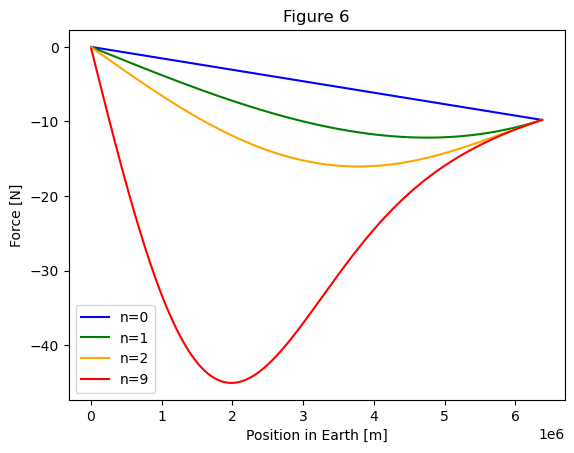

In [10]:
def density_int(r,n):
    return r**2*(1-r**2/r_earth**2)**n

r_ds = np.linspace(0, r_earth, 1000)

rhofactor_0, err_0 = quad(density_int,0,r_earth,args=(0))
rhofactor_1, err_1 = quad(density_int,0,r_earth,args=(1))
rhofactor_2, err_2 = quad(density_int,0,r_earth,args=(2))
rhofactor_9, err_9 = quad(density_int,0,r_earth,args=(9))

rho_0 = m_earth/(4*np.pi*rhofactor_0)
rho_1 = m_earth/(4*np.pi*rhofactor_1)
rho_2 = m_earth/(4*np.pi*rhofactor_2)
rho_9 = m_earth/(4*np.pi*rhofactor_9)

rh0 = np.zeros(1000)
rh1 = np.zeros(1000)
rh2 = np.zeros(1000)
rh9 = np.zeros(1000)

for i in range(1000):
    rh0[i], e0 = quad(density_int,0,r_ds[i],args=(0))
    rh1[i], e1 = quad(density_int,0,r_ds[i],args=(1))
    rh2[i], e2 = quad(density_int,0,r_ds[i],args=(2))
    rh9[i], e9 = quad(density_int,0,r_ds[i],args=(9))

M0 = rho_0*4*np.pi*rh0
M1 = rho_1*4*np.pi*rh1
M2 = rho_2*4*np.pi*rh2
M9 = rho_9*4*np.pi*rh9

F0 = -scipy.constants.G*M0/(r**2)
F1 = -scipy.constants.G*M1/(r**2)
F2 = -scipy.constants.G*M2/(r**2)
F9 = -scipy.constants.G*M9/(r**2)

fig, ax = plt.subplots()
ax.plot(r,F0,label="n=0", color="blue")
ax.plot(r,F1,label="n=1", color="green")
ax.plot(r,F2,label="n=2", color="orange")
ax.plot(r,F9,label="n=9", color="red")
ax.set_xlabel("Position in Earth [m]")
ax.set_ylabel("Force [N]")
ax.set_title("Figure 6")

ax.legend()

### Part 5, Section C (Equations of Motion)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e+00 ...  2.499e+03  2.500e+03]
        y: [[ 6.378e+06  6.378e+06 ... -6.372e+06 -6.372e+06]
            [ 0.000e+00 -9.802e+00 ... -3.448e+02 -3.351e+02]]
      sol: None
 t_events: [array([ 1.267e+03])]
 y_events: [array([[ 0.000e+00, -7.906e+03]])]
     nfev: 68
     njev: 0
      nlu: 0
  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e+00 ...  2.499e+03  2.500e+03]
        y: [[ 6.378e+06  6.378e+06 ... -2.033e+06 -2.024e+06]
            [ 0.000e+00 -9.802e+00 ...  9.659e+03  9.667e+03]]
      sol: None
 t_events: [array([ 1.097e+03])]
 y_events: [array([[-9.313e-10, -1.044e+04]])]
     nfev: 80
     njev: 0
      nlu: 0
  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000

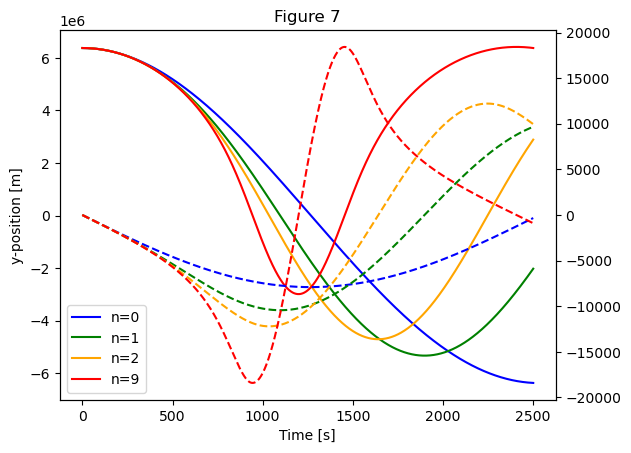

In [11]:
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline

x_data = r_ds
y_data0 = M0
y_data1 = M1
y_data2 = M2
y_data9 = M9

m0 = CubicSpline(x_data,y_data0)
m1 = CubicSpline(x_data,y_data1)
m2 = CubicSpline(x_data,y_data2)
m9 = CubicSpline(x_data,y_data9)

def derivatives_0(t,s):
    assert len(s) == 2
    y, v = s
    dydt = v
    dvdt = -scipy.constants.G*m0(y)/(y**2)
    return [dydt, dvdt]

def derivatives_1(t,s):
    assert len(s) == 2
    y, v = s
    dydt = v
    dvdt = -scipy.constants.G*m1(y)/(y**2)
    return [dydt, dvdt]

def derivatives_2(t,s):
    assert len(s) == 2
    y, v = s
    dydt = v
    dvdt = -scipy.constants.G*m2(y)/(y**2)
    return [dydt, dvdt]

def derivatives_9(t,s):
    assert len(s) == 2
    y, v = s
    dydt = v
    dvdt = -scipy.constants.G*m9(y)/(y**2)
    return [dydt, dvdt]
    
y0 = [r_earth, 0.0]
t_span = (0,2500)
t_eval = np.linspace(*t_span, 2500)

def center(t,s):
    return s[0]

soln0 = solve_ivp(derivatives_0, t_span, y0, t_eval=t_eval, events=center)
soln1 = solve_ivp(derivatives_1, t_span, y0, t_eval=t_eval, events=center)
soln2 = solve_ivp(derivatives_2, t_span, y0, t_eval=t_eval, events=center)
soln9 = solve_ivp(derivatives_9, t_span, y0, t_eval=t_eval, events=center)

t0 = soln0.t
r0 = soln0.y[0]
v0 = soln0.y[1]

t1 = soln1.t
r1 = soln1.y[0]
v1 = soln1.y[1]

t2 = soln2.t
r2 = soln2.y[0]
v2 = soln2.y[1]

t9 = soln9.t
r9 = soln9.y[0]
v9 = soln9.y[1]

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(t0,r0,label="n=0", color="blue")
ax2.plot(t0,v0,linestyle="--", color="blue")
ax.plot(t1,r1,label="n=1", color="green")
ax2.plot(t1,v1,linestyle="--", color="green")
ax.plot(t2,r2,label="n=2", color="orange")
ax2.plot(t2,v2,linestyle="--", color="orange")
ax.plot(t9,r9,label="n=9", color="red")
ax2.plot(t9,v9,linestyle="--", color="red")
ax.set_xlabel("Time [s]")
ax.set_ylabel("y-position [m]")
ax.set_title("Figure 7")

ax.legend()

print(soln0)
print(soln1)
print(soln2)
print(soln9)

print(f"""
Therefore the times to reach the center are as follows:

The time to reach the center in the n=0 case is 1267s.
The time to reach the center in the n=1 case is 1097s.
The time to reach the center in the n=2 case is 1035s.
The time to reach the center in the n=9 case is 943.8s.""")

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e+00 ...  2.999e+03  3.000e+03]
        y: [[ 1.738e+06  1.738e+06 ... -1.687e+06 -1.688e+06]
            [ 0.000e+00 -1.624e+00 ... -4.031e+02 -4.015e+02]]
      sol: None
 t_events: [array([ 1.625e+03]), array([], dtype=float64)]
 y_events: [array([[ 4.366e-11, -1.680e+03]]), array([], dtype=float64)]
     nfev: 62
     njev: 0
      nlu: 0
We observe that the object crosses the center of the moon at 1625 seconds, in contrast to 1267 seconds on Earth
 We further observe that the density of the Earth (assuming uniform density) is 5494.8674, and the density of the Moon (again assuming uniform density) is 3341.7538
 Finally, we observe that the ratio of the times is 1.2826 is roughly the same as one over the square root of the ratio of the densities 1.2823.


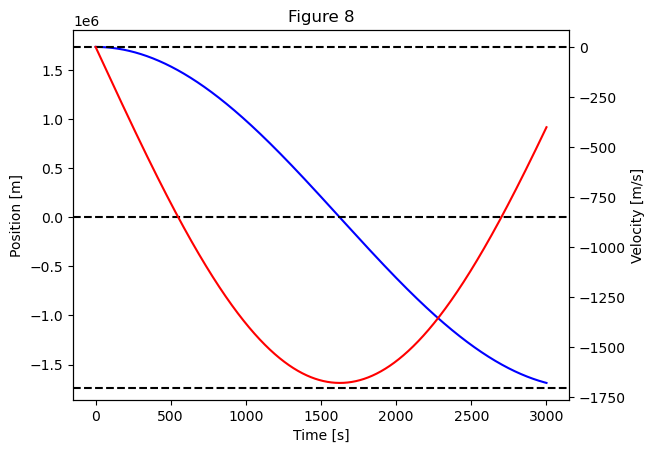

In [12]:
r_moon = 1.7381E6
m_moon = 7.35E22

def derivatives6(t,s):
    assert len(s) == 2
    y, v = s
    dydt = v
    dvdt = -scipy.constants.G*m_moon*y/r_moon**3
    return [dydt, dvdt]

def center(t,s):
    return s[0]

def other_side(t,s):
    return s[0] + r_moon

y0 = [r_moon, 0.0]
t_span = (0,3000)
t_eval = np.linspace(*t_span, 3000)

soln = solve_ivp(derivatives6, t_span, y0, t_eval=t_eval, events=[center, other_side])
t = soln.t
x = soln.y[0]
v = soln.y[1]

fig, ax = plt.subplots()
ax.plot(t,x,label="pos", color="blue")
ax2 = ax.twinx()
ax2.plot(t,v,label="vel", color="red")
ax.axhline(0,color="black", linestyle="--")
ax.axhline(r_moon,color="black", linestyle="--")
ax.axhline(-r_moon,color="black", linestyle="--")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Position [m]")
ax2.set_ylabel("Velocity [m/s]")
ax.set_title("Figure 8")

print(soln)

rho_earth = m_earth/(4/3*np.pi*r_earth**3)
rho_moon = m_moon/(4/3*np.pi*r_moon**3)

print("We observe that the object crosses the center of the moon at 1625 seconds, in contrast to 1267 seconds on Earth")
print(f" We further observe that the density of the Earth (assuming uniform density) is {rho_earth:.4f}, and the density of the Moon (again assuming uniform density) is {rho_moon:.4f}")
print(f" Finally, we observe that the ratio of the times is {1625/1267:.4f} is roughly the same as one over the square root of the ratio of the densities {np.sqrt(rho_earth/rho_moon):.4f}.")

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

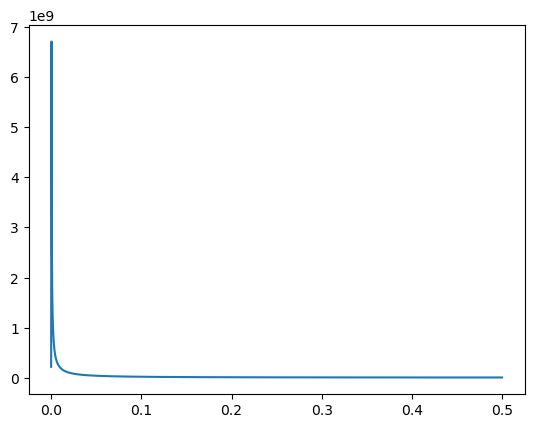

In [13]:
G_f0 = np.fft.rfft(r0)
freq0 = np.fft.rfftfreq(2*len(G_f0)-1)

fig, ax = plt.subplots(1,1)
ax.plot(freq0, np.abs(G_f0))

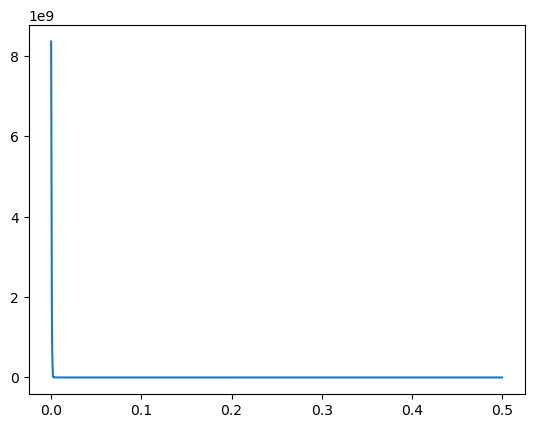

In [14]:
G_f9 = np.fft.rfft(r9)
freq9 = np.fft.rfftfreq(2*len(G_f9)-1)

fig, ax = plt.subplots(1,1)
ax.plot(freq9, np.abs(G_f9))

Describe what we see here:

For some reason I'm not actually getting any serious frequency relationship -- it's just going to 0, and I'm not really sure why. It might be because I'm trying to re-use the r0, r9 data because it's not really clear to me how it ought to be enhanced (with more integration -- what integration?). From the plot in part 5c, I can tell that the r9 case looks vaguely Lorentzian, which has a well known Fourier transform, while the r0 case is just a single sinusoid, so the single peak near 0 at least makes sense given a period on the order of thousands of seconds.